# 6. Can the table rebuild itself every Monday and refuse to ship when something breaks?

**Week 2, Thursday. Chapter 6 of 6.** Chapter 5 gave Finance's number to SQL, which moved 8 rows where pandas moved 1,340, and the growth team's table to pandas, reading from the warehouse; the table reconciles with Finance's query at Rs 19,84,00,000. This chapter makes the table rebuild itself every Monday and stop when a check fails.

> **The client asks.** "The warehouse queries are fine for Finance, but Marketing's analysts
> live in Python. Build them the table in pandas, from the warehouse, and make it refreshable in
> one run."
>
> The data platform lead, Kalpa Retail

**Who needs the answer.** The growth team, who act on Monday's table with no analyst watching
the run: the win-back code goes to every customer the table flags as lapsed. A refresh that
counts days from the wrong date sends the code to customers who bought a few weeks ago, and a
refresh that ships a broken table sends Monday's offers to the wrong people before anyone
looks.

**The questions on the way.**

1. Which of four ways should run the Monday refresh, and what does each catch?
2. What does the refresh need to be told, and what can it read from the data itself?
3. How many customers land on the win-back list when the refresh runs on Monday 19 October?
4. Which guards stop a bad Monday, and does each one fire when it should?
5. Do two runs on the same data give the same table?
6. Does the warehouse, counting on its own, find the same win-back list?

**The metric at stake.** The win-back list: customers whose last order is more than 60 days before the table's as-of
date, the last date the data covers. The number of days since a customer's last order is their
recency in days. A customer who never ordered has nothing to win back and belongs on chapter
1's first-order list instead. The 60-day line is the growth team's.

**Who else faces it.** England's public health agency ran a daily refresh that dropped rows without an error. Its own
statement said "15,841 cases between 25 September and 2 October were not included in the
reported daily COVID-19 cases" (Public Health England, 4 October 2020). The Register reported
the cause: test results were "automatically fetched in CSV format" from commercial laboratories
and stored in the older .XLS format, "that limited the number of rows to 65,536 per
spreadsheet" (The Register, 5 October 2020; both checked 1 Oct 2026). A count of rows in
against rows out on every run would have stopped it on the first day.

`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, the retail dossier, has the business behind these numbers: section 3 for GMV, section 5 for frequency and repeat rate, and section 2 for Retail-Plus, the paid tier.

**Setup.** The next cell finds the helper and opens the warehouse connection. Everything else
this chapter needs is built inside the refresh function, so one call rebuilds the table.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

ENG = kit.engine()
print("connected to the warehouse", kit.WAREHOUSE["dbname"])

connected to the warehouse kalpa


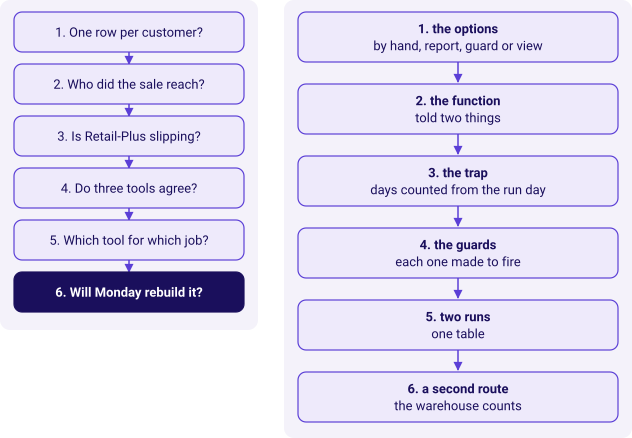

In [2]:
kit.side_by_side(
    kit.ladder(["One row per customer?", "Who did the sale reach?", "Is Retail-Plus slipping?", "Do three tools agree?", "Which tool for which job?", "Will Monday rebuild it?"], lit=5, show=False),
    kit.vflow(["1. the options\nby hand, report, guard or view", "2. the function\ntold two things", "3. the trap\ndays counted from the run day", "4. the guards\neach one made to fire", "5. two runs\none table", "6. a second route\nthe warehouse counts"], show=False),
)

## 1. Which of four ways should run the Monday refresh, and what does each catch?

| Option | How it runs | When a check fails |
|---|---|---|
| a) Rerun the notebooks by hand | An analyst runs chapters 1 to 5 and reads the numbers | The table ships if the analyst misses it |
| b) One function that reports | One call builds the table and prints PASS or FAIL for each check | The table ships, with a FAIL printed beside it |
| c) One function with guards | One call builds the table, and every check that fails raises an error | The table is not written, and the error says why |
| d) The table as a SQL view | The warehouse builds the table whenever it is read | There is nothing to fail: a view returns whatever its query gives |

The next cell sizes each against the failures the day has already met: a customer missing from
the table, a customer the feed sends twice, spend that no longer adds up to the warehouse, and a
key that repeats.

option,what happens when any of the four arrives,failures stopped
a) by hand,caught only if the analyst happens to notice,0
b) reports,"a FAIL is printed beside the table, and the table ships",0
c) guards,"the run stops with an error, and nothing is written",4
d) a SQL view,"no check runs, and SQL has no single argument like validate",0


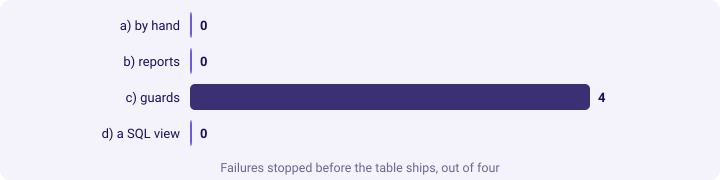

In [3]:
failures = ["a customer missing", "a customer sent twice", "spend off the warehouse", "a repeated key"]
options = [("a) by hand", "caught only if the analyst happens to notice", 0),
           ("b) reports", "a FAIL is printed beside the table, and the table ships", 0),
           ("c) guards", "the run stops with an error, and nothing is written", len(failures)),
           ("d) a SQL view", "no check runs, and SQL has no single argument like validate", 0)]
kit.table(["option", "what happens when any of the four arrives", "failures stopped"], options,
          caption="The four failures: " + "; ".join(failures))
kit.bars([(name, n) for name, _, n in options], lit=(2,),
         title="Failures stopped before the table ships, out of four")

**The best-fit call: c, one function with guards.** It is the only option that stops a bad
Monday before the growth team acts on it, and it keeps the table in pandas, where chapter 5 put
it. **The fact that would change it:** the table's readers querying it from the warehouse, such
as a dashboard. Then d, with the same checks moved into the warehouse's own tests.

## 2. What does the refresh need to be told, and what can it read from the data itself?

A refresh that runs unattended should be told as little as possible, because every input is a
chance to be told something wrong. The function below is chapters 1 and 2 in one call: the
customer list as the spine, the three numbers from the orders, the sale's first exposure, both
merges validated.

**Predict before you run.** What must the function be told? a) the day to count recency from;
b) the warehouse connection and the feed's path; c) the number of customers; d) the total spend.

the function is told,it reads from the data
the warehouse connection,the orders and the customer list
the feed's path,the first exposure of every reached customer
,"340 customers, Rs 19,84,00,000 of spend"


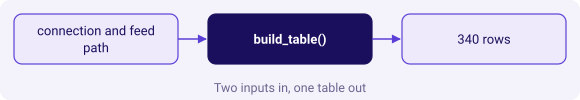

In [4]:
def build_table(engine, feed_path):
    """Chapters 1 and 2 in one call: every customer, three numbers each, the sale's first touch."""
    o = pd.read_sql("SELECT order_id, customer_id, order_date, amount FROM orders", engine,
                    parse_dates=["order_date"])
    c = pd.read_sql("SELECT customer_id, segment FROM customers", engine)
    e = pd.read_csv(feed_path, parse_dates=["exposed_date"])
    agg = (o.groupby("customer_id")
            .agg(last_order=("order_date", "max"), frequency=("order_id", "count"), spend=("amount", "sum"))
            .reset_index())
    t = c.merge(agg, on="customer_id", how="left", validate="one_to_one")
    first = e.sort_values("exposed_date").drop_duplicates("customer_id", keep="first")
    t = t.merge(first[["customer_id", "exposed_date"]], on="customer_id", how="left", validate="one_to_one")
    return t.assign(frequency=t["frequency"].fillna(0).astype("int64"), spend=t["spend"].fillna(0),
                    reached=t["exposed_date"].notna()), o

FEED_PATH = kit.data_dir() / "C2_W02_D04_exposure_STUDENT.csv"

table, o = build_table(ENG, FEED_PATH)
kit.table(["the function is told", "it reads from the data"],
          [("the warehouse connection", "the orders and the customer list"),
           ("the feed's path", "the first exposure of every reached customer"),
           ("", f"{len(table)} customers, {kit.rupees(table['spend'].sum())} of spend")],
          caption="What build_table needs, and what it finds for itself")
kit.flow(["connection and feed path", "build_table()", f"{len(table)} rows"], lit=1,
         title="Two inputs in, one table out")
kit.check("the function rebuilds chapter 2's table", len(table) == 340 and int(table["reached"].sum()) == 130)
kit.check("spend adds back to the warehouse", table["spend"].sum() == 198_400_000)

**What happened.** The answer is b. Everything else, the customers, their numbers and the sale,
the function reads from the data, so it cannot be told a stale count. Recency is the one column
still missing, and it needs a date to count to.

## 3. How many customers land on the win-back list when the refresh runs on Monday 19 October?

**The plausible wrong answer.** Recency is the days since a customer's last order, and the
hurried analyst counts them to `pd.Timestamp.today()`, so the refresh looks current whenever it
runs. The table first ships on Monday 19 October, the first Monday after this session; the cell
pins that date so the number below is exactly what that refresh would have sent.

**Predict before you run.** How many customers land on the win-back list, no order in 60 days?
a) 111; b) 166; c) 301; d) 55.

In [5]:
RUN_DAY = pd.Timestamp("2026-10-19")      # what pd.Timestamp.today() returns on the first Monday refresh
wrong = (RUN_DAY - table["last_order"]).dt.days
wrong_list = int((wrong > 60).sum())
kit.stats([(wrong_list, "on the win-back list", "no order in 60 days, counted to the run day"),
           (int(wrong.min()), "smallest recency, in days", "the most recent buyer, as the table says")],
          caption="The Monday 19 October refresh, as the hurried function would ship it")

**What happened.** The answer is b, 166 customers.

**Why it is wrong.** The warehouse's last order is dated 28 September 2026; nothing after it has
been loaded. Counted to 19 October, every customer looks 21 days staler than the data says, so
customers who bought in the weeks before the data ends are sent a win-back code. Run the same
refresh a week later with no new data and the list grows again, because the table has become a
function of the calendar. The check that catches it: somebody always bought on the data's last
day, so the smallest recency in an honest table is 0. Here it is 21.

In [6]:
AS_OF = o["order_date"].max()
kit.check("the data's last date is 28 September 2026", AS_OF == pd.Timestamp("2026-09-28"), str(AS_OF.date()))
kit.check("the hurried recency's smallest value is 21 days, the gap between the two dates",
          int(wrong.min()) == (RUN_DAY - AS_OF).days, f"{int(wrong.min())} days")
mondays = pd.to_datetime(["2026-10-19", "2026-10-26", "2026-11-02"])
grows = [int(((m - table["last_order"]).dt.days > 60).sum()) for m in mondays]
kit.check("with no new data, the hurried list grows every Monday", grows == sorted(grows) and grows[0] < grows[-1],
          ", ".join(f"{m.date()}: {n}" for m, n in zip(mondays, grows)))

**The fix, and what changed.** Count to the data's own last date, `o["order_date"].max()`, and
write that date into the table as its `as_of` column, so the growth team can see what "60 days"
was counted from. The list falls from 166 to 111; the 55 customers who came off it had ordered
within 60 days of 28 September.

The run day keeps one honest use. The gap between it and the as-of date is the data's age: 21
days on 19 October, the same 21 the hurried table showed as its smallest recency. A table whose
orders end three weeks before the run is a stale load, and the growth team should hear that
before any code is sent, so the age is reported beside the table instead of hidden inside every
customer's recency.

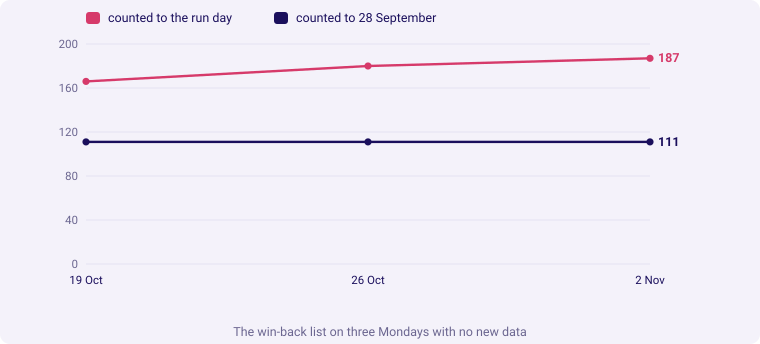

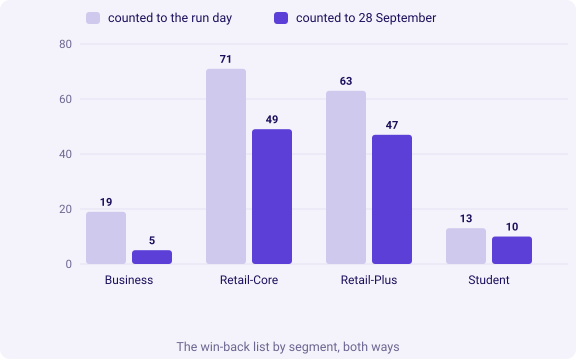

In [7]:
table = table.assign(as_of=AS_OF, recency_days=(AS_OF - table["last_order"]).dt.days)
table = table.assign(lapsed=table["recency_days"] > 60)
right_list = int(table["lapsed"].sum())
kit.line(["19 Oct", "26 Oct", "2 Nov"], [("counted to the run day", grows, "bad"),
                                         ("counted to 28 September", [right_list] * 3, "lit")],
         title="The win-back list on three Mondays with no new data")
by_seg = pd.DataFrame({"counted to the run day": (wrong > 60).groupby(table["segment"]).sum(),
                       "counted to 28 September": table["lapsed"].groupby(table["segment"]).sum()})
kit.columns(by_seg.index.tolist(), [(c, by_seg[c].astype(int).tolist()) for c in by_seg.columns],
            title="The win-back list by segment, both ways")
kit.check("the honest smallest recency is 0 days", table["recency_days"].min() == 0)
kit.check("the honest win-back list holds 111 customers", right_list == 111, f"{right_list}")
age = (RUN_DAY - AS_OF).days
kit.check("the data's age on 19 October, reported beside the table, is 21 days", age == 21, f"{age} days")

## 4. Which guards stop a bad Monday, and does each one fire when it should?

A guard is a check that raises an error, so a table that fails it is never written. Four guards
cover the failures the day has met. Two compare the table with counts the warehouse gives on its
own query, read again on every call: as many rows as the customer list, and spend equal to the
warehouse's total. Two check the table's own shape: one row per customer, and a smallest recency
of 0. A guard earns trust once it has been seen to fire, so the cell breaks a copy of the table
in one way at a time.

**Predict before you run.** A copy with one customer's row repeated: which guards fire?
a) only the unique-key guard; b) the unique-key and row-count guards; c) the unique-key,
row-count and spend guards; d) all four.

the table,guards that fire
the honest table,none
one customer's row repeated,"one row per customer, rows equal the customer list, spend equals the warehouse"
recency counted to the run day,smallest recency is 0
no-order customers dropped,rows equal the customer list


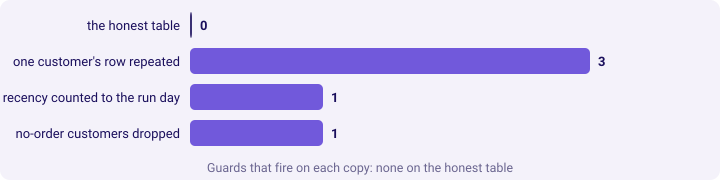

In [8]:
def guard_failures(t):
    """The guards that fail on a table: two against the warehouse's counts, read on every call."""
    controls = kit.sql("SELECT (SELECT count(*) FROM customers) AS customers, "
                       "(SELECT sum(amount) FROM orders) AS spend")[0]
    failed = []
    if not t["customer_id"].is_unique:
        failed.append("one row per customer")
    if len(t) != controls["customers"]:
        failed.append("rows equal the customer list")
    if t["spend"].sum() != float(controls["spend"]):
        failed.append("spend equals the warehouse")
    if t["recency_days"].min() != 0:
        failed.append("smallest recency is 0")
    return failed

repeated = pd.concat([table, table[table["customer_id"] == "C-0152"]])
wall_clock = table.assign(recency_days=(RUN_DAY - table["last_order"]).dt.days)
dropped = table[table["frequency"] > 0]
trials = [("the honest table", table), ("one customer's row repeated", repeated),
          ("recency counted to the run day", wall_clock), ("no-order customers dropped", dropped)]
kit.table(["the table", "guards that fire"],
          [(name, ", ".join(guard_failures(t)) or "none") for name, t in trials],
          caption="Each broken copy, and the guards it trips")
kit.bars([(name, len(guard_failures(t))) for name, t in trials], lit=(0,),
         title="Guards that fire on each copy: none on the honest table")

In [9]:
kit.check("the honest table passes every guard", guard_failures(table) == [])
kit.check("a repeated row trips the key, row-count and spend guards",
          guard_failures(repeated) == ["one row per customer", "rows equal the customer list", "spend equals the warehouse"])
kit.check("recency counted to the run day trips the recency guard", guard_failures(wall_clock) == ["smallest recency is 0"])
kit.check("dropping customers with no orders trips the row-count guard",
          guard_failures(dropped) == ["rows equal the customer list"])

**What happened.** The answer is c: a repeated row breaks the unique key, adds a row and adds
that customer's spend a second time, so three guards fire; the recency guard does not, because
the repeated customer's recency is the same. Each broken copy trips at least one guard and the
honest table trips none, so the guards tell a broken Monday from an honest one. In the refresh, a
guard that fails raises an error, so the table is not written. Inside the refresh the recency
guard passes by construction, because the as-of date comes from the same orders; it is there
for the Monday someone edits the refresh to count to the calendar, and the third copy shows it
would fire.

## 5. Do two runs on the same data give the same table?

The whole refresh is now one function: build, count recency to the data's last date, flag, and
run every guard, raising an error on the first that fails. A refresh the growth team can trust
gives the same table whenever it runs on the same data, whatever the calendar says.

**Predict before you run.** The honest refresh runs on two different Mondays with no new data.
How many customers differ between the two tables? a) 55; b) 14; c) 0; d) 111.

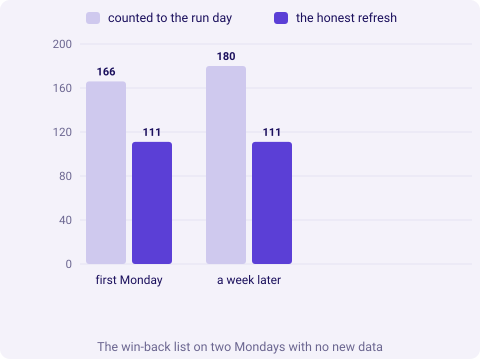

In [10]:
def refresh(engine, feed_path):
    """The Monday refresh: the table, counted to the data's own last date, and every guard."""
    t, orders_read = build_table(engine, feed_path)
    as_of = orders_read["order_date"].max()
    t = t.assign(as_of=as_of, recency_days=(as_of - t["last_order"]).dt.days)
    t = t.assign(lapsed=t["recency_days"] > 60)
    failed = guard_failures(t)
    if failed:
        raise ValueError("the refresh stopped; guards failed: " + ", ".join(failed))
    return t

monday_1 = refresh(ENG, FEED_PATH)          # run on one Monday
monday_2 = refresh(ENG, FEED_PATH)          # and again, a week later, with no new data
hurried = [int(((m - monday_1["last_order"]).dt.days > 60).sum()) for m in mondays[:2]]
kit.columns(["first Monday", "a week later"], [("counted to the run day", hurried),
                                              ("the honest refresh", [int(monday_1["lapsed"].sum()), int(monday_2["lapsed"].sum())])],
            title="The win-back list on two Mondays with no new data", width=480)
kit.check("two honest runs give the same table, cell for cell", monday_1.equals(monday_2))
kit.check("the hurried version gives two different lists", hurried[0] != hurried[1], f"{hurried[0]} and {hurried[1]}")

**What happened.** The answer is c: the two honest tables are equal cell for cell, because
nothing in the refresh reads the calendar. The hurried version, counting to the run day, sent
166 codes on the first Monday and 180 a week later, with no new data at all.

> **Kavya's review.** "The table carries its as-of date, the smallest recency is 0, and a run that
> fails a guard writes nothing. That is a refresh I will let Marketing act on without me."

## 6. Does the warehouse, counting on its own, find the same win-back list?

The refresh counted the list with pandas: a `groupby`, a merge and a subtraction. The warehouse
can count it with none of that code: each customer's last order, the table's own last date, and
the customers more than 60 days apart. Subtracting two dates in Postgres gives whole days.

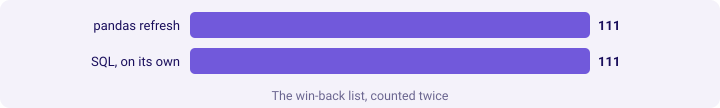

In [11]:
WIN_BACK = """WITH last  AS (SELECT customer_id, max(order_date) AS last_order FROM orders GROUP BY customer_id),
     as_of AS (SELECT max(order_date) AS d FROM orders)
SELECT count(*) AS win_back
FROM   last, as_of
WHERE  as_of.d - last.last_order > 60;"""
by_sql = int(kit.sql(WIN_BACK)[0]["win_back"])
kit.bars([("pandas refresh", int(monday_1["lapsed"].sum())), ("SQL, on its own", by_sql)],
         title="The win-back list, counted twice")
kit.check("SQL finds the same 111 customers the refresh flagged", by_sql == int(monday_1["lapsed"].sum()) == 111)

**When to switch.** The refresh is the route for the table; the query is the route for anyone
who wants to confirm the list's size without Python, such as the growth team's lead before a
send.

### How would you answer an interviewer's questions on a refresh that runs unattended?

**[F] How do you compute recency in a job that runs every week?** "From the data's last loaded
date, carried in the table as its as-of date. Counted to the wall clock, two runs on the same
data disagree and the list grows every week with nothing new loaded. The wall clock keeps one
job: the gap between the run day and the as-of date is the data's age, and I report it with the
table, because a weekly table whose orders end three weeks back is a stale load the growth team
should hear about before any code is sent. The check on the count itself is that the smallest
recency is 0."

**[D] What would you guard in a weekly refresh, and why those?** "The invariants a wrong table
breaks: one row per key, rows equal to the source list, the money equal to the warehouse's
total, and a smallest recency of 0. The row and money guards compare with counts the warehouse
gives on its own query, read on every run; the key and recency guards check the table's own
shape. Each raises an error, because a check that only prints lets the table ship. I also report
the data's age, since no guard on the table can see a load that never arrived."

**[F] Your refresh stopped on a guard on Monday, before the send. What do you tell Marketing?** "That
this Monday's table did not ship, which guard stopped it and what it found, and that last week's
table is still the one to use until I fix the cause. A send that waits a day costs less than
win-back codes sent to customers who bought last month."

### Going deeper: how does pandas mirror Wednesday's falling flag?

Wednesday flagged members whose monthly spend fell two months running with `LAG` in SQL, and
found two traps on the way: reading another customer's month without `PARTITION BY`, and counting
a skipped month as a fall. In pandas, `groupby("customer_id")["spend"].shift(1)` is `LAG`
partitioned by customer, and shifting the month the same way lets the check require that the two
earlier readings are the two calendar months before. The cell compares the pandas flag with
the warehouse's, customer by customer, without listing anyone.

In [12]:
monthly = (o.assign(month=o["order_date"].dt.to_period("M"))
            .groupby(["customer_id", "month"], as_index=False)["amount"].sum()
            .rename(columns={"amount": "spend"})
            .sort_values(["customer_id", "month"]))
g = monthly.groupby("customer_id")
monthly = monthly.assign(spend_1=g["spend"].shift(1), spend_2=g["spend"].shift(2),
                         month_1=g["month"].shift(1), month_2=g["month"].shift(2))
sep = pd.Period("2026-09", "M")
is_falling = ((monthly["month"] == sep) & (monthly["month_1"] == sep - 1) & (monthly["month_2"] == sep - 2)
              & (monthly["spend"] < monthly["spend_1"]) & (monthly["spend_1"] < monthly["spend_2"]))
flag_pd = set(monthly.loc[is_falling, "customer_id"])
FALLING = """WITH monthly AS (
         SELECT customer_id, date_trunc('month', order_date)::date AS month, sum(amount) AS spend
         FROM   orders
         GROUP  BY customer_id, date_trunc('month', order_date)),
     lagged AS (
         SELECT customer_id, month, spend,
                lag(spend, 1) OVER w AS spend_before, lag(spend, 2) OVER w AS spend_two_before,
                lag(month, 1) OVER w AS month_before, lag(month, 2) OVER w AS month_two_before
         FROM   monthly
         WINDOW w AS (PARTITION BY customer_id ORDER BY month))
SELECT count(*) AS falling
FROM   lagged
WHERE  month = DATE '2026-09-01'
  AND  month_before = DATE '2026-08-01' AND month_two_before = DATE '2026-07-01'
  AND  spend < spend_before AND spend_before < spend_two_before;"""
flag_sql_count = int(kit.sql(FALLING)[0]["falling"])
LIST = FALLING.replace("SELECT count(*) AS falling", "SELECT customer_id")
flag_sql = {r["customer_id"] for r in kit.sql(LIST)}
kit.check("pandas and SQL flag the same customers, customer by customer", flag_pd == flag_sql)
kit.check("and the same number of them", len(flag_pd) == flag_sql_count)

**The answers, question by question.**

1. One function with guards runs the refresh: it is the only option that stops all four of the
   day's failures before the table ships.
2. The refresh is told two things, the warehouse connection and the feed's path, and reads the
   340 customers and their numbers from the data.
3. Counted to the run day, 19 October, the win-back list holds 166 customers and the smallest
   recency is 21 days; counted to the data's last date, 28 September, it holds 111, and the 21
   days become the data's age, reported beside the table.
4. Four guards stop a bad Monday, and each broken copy trips at least one while the honest table
   trips none.
5. Two honest runs give the same table cell for cell; the hurried version gave 166 and then 180.
6. The warehouse, counting on its own, finds the same 111.

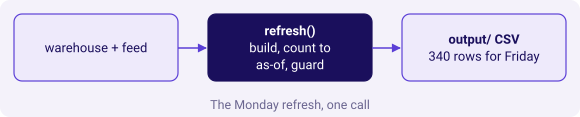

Next: the escalated case builds the full Monday table alone, with both flags and one reshaped view.


In [13]:
import pathlib
out = pathlib.Path("output")
out.mkdir(exist_ok=True)
monday_1.to_csv(out / "C2_W02_D04_customer_table_STUDENT.csv", index=False)
kit.flow(["warehouse + feed", "refresh()\nbuild, count to as-of, guard", "output/ CSV\n340 rows for Friday"],
         lit=1, title="The Monday refresh, one call")
kit.check("the refreshed table was written for Friday", (out / "C2_W02_D04_customer_table_STUDENT.csv").exists())
kit.check_summary()
print("Next: the escalated case builds the full Monday table alone, with both flags and one reshaped view.")